# 02 - Pitch Control

**SDC Master's Final Project — soccernet-setpiece-vision**

CRISP-DM phase 4 (Modeling). Computes Pitch Control (PC) surfaces on both **pipeline** (Soccana + TVCalib) and **GT** detections for the same clips/frames.

**Model.** Laurie Shaw's Friends-of-Tracking implementation (Spearman 2018-style time-to-intercept model), vendored inline and parameterised.

**Static-frame caveat.** SoccerNet GSR set-piece clips are sampled at the action moment, so velocities are not available. We assume **zero velocity** for every player. This converts PC into an *instantaneous* surface — i.e. ignoring momentum — but keeps the comparison fair: pipeline and GT receive identical model + assumptions, so any distributional difference is driven by detection / homography quality, not motion modelling.

**Attacking team.** Determined per frame by which team has the player closest to the ball.

**Outputs.**
- `outputs/pitch_control.parquet` — one row per (clip_id, frame_idx, track) with summary metrics on the PC surface.

## 0. Setup and Imports

In [1]:
import json
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GSR_ROOT = Path(os.getenv("SOCCERNET_LOCAL_DIR", "/Volumes/MPH-ExternalStorage/soccernet-gsr")) / "gamestate-2024"
PITCH_LENGTH_M = 105.0
PITCH_WIDTH_M = 68.0

# Pitch control grid (cells across length / width)
GRID_NX = 60   # ~1.75 m per cell
GRID_NY = 40   # ~1.7  m per cell

# Laurie Shaw / Spearman model params (Friends of Tracking defaults)
MAX_SPEED = 5.0       # m/s
REACTION_TIME = 0.7   # s
SIGMA = 0.45          # logistic slope on TTI
LAMBDA = 4.3          # rate constant for ball-control
TIME_TO_INTERCEPT_SIGMOID_K = np.pi / (np.sqrt(3.0) * SIGMA)

print(f"Outputs: {OUTPUTS_DIR.relative_to(PROJECT_ROOT)}")

Outputs: outputs


## 1. Load Detections + Ball Positions

In [2]:
pipeline_df = pd.read_parquet(OUTPUTS_DIR / "detections_soccana_tvcalib.parquet")
gt_df = pd.read_parquet(OUTPUTS_DIR / "detections_gt_full.parquet")
print("pipeline_df:", pipeline_df.shape)
print("gt_df      :", gt_df.shape)
pipeline_df.head()

pipeline_df: (16090, 16)
gt_df      : (18539, 9)


,split,clip_id,action_class,frame_idx,track_id,x_m,y_m,team_kmeans,conf,hsv_h,hsv_s,hsv_v,x1_px,y1_px,x2_px,y2_px
0,train,SNGS-066,Direct free-kick,1,1,1.804003,33.928173,1,0.839349,139.846914,132.212346,188.627160,297.462372,406.398407,326.325012,497.486603
1,train,SNGS-066,Direct free-kick,1,2,23.963033,40.430637,0,0.818840,52.842713,87.747475,176.240981,986.003906,533.081909,1027.456787,641.989136
2,train,SNGS-066,Direct free-kick,1,3,31.267733,23.632865,0,0.817302,50.850000,113.620370,154.705556,1718.059204,440.317993,1757.381470,531.873779
3,train,SNGS-066,Direct free-kick,1,4,22.463103,29.814661,0,0.810976,55.026442,75.894231,181.100962,1198.275146,453.859192,1228.881958,542.917603
4,train,SNGS-066,Direct free-kick,1,5,16.790455,39.702222,0,0.808499,54.722222,65.164751,188.151341,677.332703,501.225983,714.053406,598.242798


In [3]:
def parse_ball_position(clip_path: Path, frame_idx: int) -> tuple[float, float] | None:
    """Read SoccerNet GT ball annotation for a given frame, return metric pitch (x_m, y_m)."""
    label_path = clip_path / "Labels-GameState.json"
    if not label_path.is_file():
        return None
    labels = json.load(open(label_path))
    target = f"{frame_idx:06d}.jpg"
    image_id = next((img["image_id"] for img in labels["images"] if img.get("file_name") == target), None)
    if image_id is None:
        return None
    for a in labels["annotations"]:
        if a.get("image_id") != image_id or a.get("category_id") != 4:
            continue
        bp = a.get("bbox_pitch")
        if not bp:
            continue
        x_centred = bp.get("x_bottom_middle")
        y_centred = bp.get("y_bottom_middle")
        if x_centred is None or y_centred is None:
            continue
        return float(x_centred) + PITCH_LENGTH_M / 2, float(y_centred) + PITCH_WIDTH_M / 2
    return None


# Build ball lookup keyed by (split, clip_id, frame_idx)
frame_keys = (
    pd.concat([pipeline_df[["split", "clip_id", "frame_idx"]], gt_df[["split", "clip_id", "frame_idx"]]], ignore_index=True)
    .drop_duplicates()
)
ball_rows = []
for _, row in frame_keys.iterrows():
    cp = GSR_ROOT / row["split"] / row["clip_id"]
    bp = parse_ball_position(cp, int(row["frame_idx"]))
    ball_rows.append({
        "split": row["split"], "clip_id": row["clip_id"], "frame_idx": int(row["frame_idx"]),
        "ball_x_m": bp[0] if bp else np.nan, "ball_y_m": bp[1] if bp else np.nan,
    })
balls_df = pd.DataFrame(ball_rows)
print(f"frames: {len(balls_df)}  |  with ball: {balls_df['ball_x_m'].notna().sum()}")
balls_df.head()

frames: 1023  |  with ball: 949


,split,clip_id,frame_idx,ball_x_m,ball_y_m
0,train,SNGS-066,1,23.821790,9.184923
1,train,SNGS-066,2,23.821646,9.186275
2,train,SNGS-066,3,23.821409,9.189015
3,train,SNGS-066,4,23.821296,9.193514
4,train,SNGS-066,5,23.821590,9.200247


## 2. Pitch Control Model (vendored Laurie Shaw)

Time-to-intercept: each player accelerates to `MAX_SPEED` after `REACTION_TIME`, in a straight line to the target point.
Probability of reaching the point first follows a logistic on the team-min TTI difference.
Ball-control build-up uses an exponential rate `LAMBDA`.
Static-frame mode: initial velocity is zero for every player.

**Vendor reference (locked for reproducibility):**
- Source: `https://github.com/Friends-of-Tracking-Data-FoTD/LaurieOnTracking`
- Reference commit: `21f4c2d` (master, 2020-09-15) — base implementation of `Pitch_Control.py`.
- Adapted in-notebook (no external import) to remove tracking-data dependency: zero-velocity, single-frame input.
- Parameters fixed: `MAX_SPEED=5.0 m/s`, `REACTION_TIME=0.7 s`, `SIGMA=0.45 s`, sigmoid k=`pi/(sqrt(3)*SIGMA)`.
- Grid: `60 x 40` (1.75 m x 1.70 m cells on 105 x 68 m pitch).
- Any deviation from these constants invalidates the validation in nb04.


In [4]:
def time_to_intercept(player_xy: np.ndarray, target_xy: np.ndarray) -> np.ndarray:
    """Static-frame TTI: REACTION_TIME + straight-line distance / MAX_SPEED.

    player_xy: (N, 2) player positions in metres.
    target_xy: (M, 2) grid point positions in metres.
    Returns (N, M) TTI in seconds.
    """
    diff = player_xy[:, None, :] - target_xy[None, :, :]
    dist = np.linalg.norm(diff, axis=2)
    return REACTION_TIME + dist / MAX_SPEED


def pitch_control_surface(att_xy: np.ndarray, def_xy: np.ndarray, ball_xy: tuple[float, float],
                          nx: int = GRID_NX, ny: int = GRID_NY) -> np.ndarray:
    """Compute attacking-team Pitch Control surface on a regular grid.

    Returns ny x nx array of attacking-control probabilities in [0, 1].
    Defending control = 1 - attacking control.
    """
    xs = np.linspace(0.0, PITCH_LENGTH_M, nx)
    ys = np.linspace(0.0, PITCH_WIDTH_M, ny)
    grid = np.array(np.meshgrid(xs, ys)).reshape(2, -1).T  # (nx*ny, 2)

    if len(att_xy) == 0 or len(def_xy) == 0:
        return np.full((ny, nx), 0.5)

    tti_att = time_to_intercept(att_xy, grid).min(axis=0)  # (M,)
    tti_def = time_to_intercept(def_xy, grid).min(axis=0)

    # Logistic on the TTI difference: P(att first) = 1 / (1 + exp(k*(tti_att - tti_def)))
    delta = tti_att - tti_def
    p_att = 1.0 / (1.0 + np.exp(TIME_TO_INTERCEPT_SIGMOID_K * delta))
    return p_att.reshape(ny, nx)

## 3. Compute PC per (clip, frame, track)

For each frame: split players into attacking / defending by ball-proximity (the team whose closest player is nearest the ball is the attacker), compute PC surface, summarise.

In [5]:
def split_attack_defend(players_xy: np.ndarray, team_labels: np.ndarray, ball_xy: tuple[float, float]):
    """Pick attacking team = whichever of the two teams is closer to the ball.
    Returns (att_xy, def_xy, attacking_label).
    """
    bx, by = ball_xy
    teams = [t for t in np.unique(team_labels) if t is not None and t != -1 and not (isinstance(t, float) and np.isnan(t))]
    if len(teams) < 2:
        return players_xy, np.zeros((0, 2)), teams[0] if teams else None
    # min distance from ball per team
    min_d = {}
    for t in teams:
        mask = team_labels == t
        if mask.sum() == 0:
            continue
        d = np.linalg.norm(players_xy[mask] - np.array([bx, by]), axis=1)
        min_d[t] = d.min()
    att_team = min(min_d, key=min_d.get)
    def_team = [t for t in min_d if t != att_team][0]
    return players_xy[team_labels == att_team], players_xy[team_labels == def_team], att_team


def summarise_surface(pc: np.ndarray, ball_xy: tuple[float, float]) -> dict:
    """Distributional summary metrics of an attacking-team PC surface."""
    bx, by = ball_xy
    ny, nx = pc.shape
    xs = np.linspace(0.0, PITCH_LENGTH_M, nx)
    ys = np.linspace(0.0, PITCH_WIDTH_M, ny)
    # cell at ball
    ix = int(np.clip(round((bx / PITCH_LENGTH_M) * (nx - 1)), 0, nx - 1))
    iy = int(np.clip(round((by / PITCH_WIDTH_M) * (ny - 1)), 0, ny - 1))
    pc_at_ball = float(pc[iy, ix])
    # masks
    XX, YY = np.meshgrid(xs, ys)
    pen_left  = (XX <= 16.5) & (YY >= 13.84) & (YY <= 54.16)
    pen_right = (XX >= PITCH_LENGTH_M - 16.5) & (YY >= 13.84) & (YY <= 54.16)
    in_pen = pen_left | pen_right
    att_third_left  = XX <= PITCH_LENGTH_M / 3
    att_third_right = XX >= 2 * PITCH_LENGTH_M / 3
    # Choose the side closer to the ball as the relevant attacking third / box
    if bx < PITCH_LENGTH_M / 2:
        att_third = att_third_left
        att_box   = pen_left
    else:
        att_third = att_third_right
        att_box   = pen_right
    return {
        "pc_mean": float(pc.mean()),
        "pc_at_ball": pc_at_ball,
        "pc_in_box": float(pc[att_box].mean()) if att_box.any() else np.nan,
        "pc_in_third": float(pc[att_third].mean()) if att_third.any() else np.nan,
        "pc_area_gt_0p5": float((pc > 0.5).mean()),
    }


def process_track(df: pd.DataFrame, track_name: str, team_col: str, balls: pd.DataFrame) -> pd.DataFrame:
    out = []
    for (split, clip_id, frame_idx), g in df.groupby(["split", "clip_id", "frame_idx"]):
        ball_row = balls[(balls["split"] == split) & (balls["clip_id"] == clip_id) & (balls["frame_idx"] == frame_idx)]
        if ball_row.empty or ball_row["ball_x_m"].isna().any():
            continue
        ball_xy = (float(ball_row["ball_x_m"].iloc[0]), float(ball_row["ball_y_m"].iloc[0]))
        players_xy = g[["x_m", "y_m"]].to_numpy()
        teams = g[team_col].to_numpy()
        att_xy, def_xy, att_label = split_attack_defend(players_xy, teams, ball_xy)
        if len(att_xy) == 0 or len(def_xy) == 0:
            continue
        pc = pitch_control_surface(att_xy, def_xy, ball_xy)
        m = summarise_surface(pc, ball_xy)
        action_class = g["action_class"].iloc[0] if "action_class" in g.columns else None
        out.append({
            "split": split, "clip_id": clip_id, "frame_idx": int(frame_idx),
            "track": track_name, "action_class": action_class,
            "n_attackers": int(len(att_xy)), "n_defenders": int(len(def_xy)),
            "ball_x_m": ball_xy[0], "ball_y_m": ball_xy[1],
            **m,
        })
    return pd.DataFrame(out)


pipe_pc = process_track(pipeline_df, track_name="pipeline", team_col="team_kmeans", balls=balls_df)
gt_pc   = process_track(gt_df,        track_name="gt",       team_col="team",        balls=balls_df)
print("pipeline PC frames:", len(pipe_pc))
print("GT       PC frames:", len(gt_pc))
pipe_pc.head()

pipeline PC frames: 940
GT       PC frames: 949


,split,clip_id,frame_idx,track,action_class,n_attackers,n_defenders,ball_x_m,ball_y_m,pc_mean,pc_at_ball,pc_in_box,pc_in_third,pc_area_gt_0p5
0,test,SNGS-116,1,pipeline,Corner,9,6,104.502290,0.871562,0.157534,0.891062,0.628614,0.419588,0.156250
1,test,SNGS-116,2,pipeline,Corner,8,5,104.502725,0.871324,0.160434,0.936103,0.648767,0.432050,0.159167
2,test,SNGS-116,3,pipeline,Corner,8,7,104.503573,0.870849,0.157801,0.909711,0.634311,0.424856,0.152500
3,test,SNGS-116,4,pipeline,Corner,8,7,104.504795,0.870136,0.154959,0.905106,0.627894,0.415453,0.140833
4,test,SNGS-116,5,pipeline,Corner,9,6,104.506331,0.869186,0.157009,0.929629,0.639809,0.422017,0.140000


## 4. Sample Visualisations

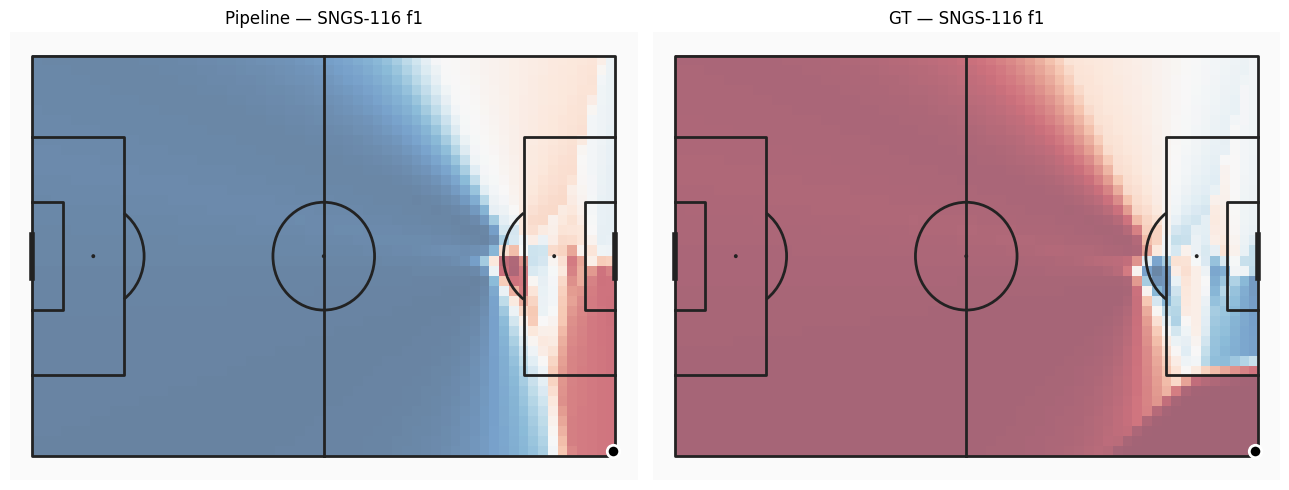

In [6]:
def plot_pc(ax, pc, ball_xy, title):
    pitch = Pitch(pitch_type="custom", pitch_length=PITCH_LENGTH_M, pitch_width=PITCH_WIDTH_M,
                  line_color="#222", pitch_color="#fafafa")
    pitch.draw(ax=ax)
    ax.imshow(pc, extent=(0, PITCH_LENGTH_M, PITCH_WIDTH_M, 0), origin="upper",
              cmap="RdBu_r", vmin=0, vmax=1, alpha=0.6, aspect="auto")
    ax.scatter([ball_xy[0]], [ball_xy[1]], c="black", s=80, marker="o", edgecolor="white", linewidth=2)
    ax.set_title(title)


# Pick first clip with both pipeline and GT PC
common = pd.merge(
    pipe_pc[["split", "clip_id", "frame_idx"]],
    gt_pc[["split", "clip_id", "frame_idx"]],
    on=["split", "clip_id", "frame_idx"],
)
if not common.empty:
    sample = common.iloc[0]
    sel = lambda df, col: df[(df["split"] == sample["split"]) & (df["clip_id"] == sample["clip_id"]) & (df["frame_idx"] == sample["frame_idx"])]
    p_g = sel(pipeline_df, "team_kmeans")
    g_g = sel(gt_df, "team")
    ball_xy = balls_df[(balls_df["split"] == sample["split"]) & (balls_df["clip_id"] == sample["clip_id"]) & (balls_df["frame_idx"] == sample["frame_idx"])][["ball_x_m", "ball_y_m"]].iloc[0].tolist()
    p_att, p_def, _ = split_attack_defend(p_g[["x_m", "y_m"]].to_numpy(), p_g["team_kmeans"].to_numpy(), ball_xy)
    g_att, g_def, _ = split_attack_defend(g_g[["x_m", "y_m"]].to_numpy(), g_g["team"].to_numpy(), ball_xy)
    pc_pipe = pitch_control_surface(p_att, p_def, ball_xy)
    pc_gt   = pitch_control_surface(g_att, g_def, ball_xy)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    plot_pc(axes[0], pc_pipe, ball_xy, f"Pipeline — {sample['clip_id']} f{sample['frame_idx']}")
    plot_pc(axes[1], pc_gt,   ball_xy, f"GT — {sample['clip_id']} f{sample['frame_idx']}")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "07_pc_sample_pipeline_vs_gt.png", dpi=150)
    plt.show()

## 5. Save Output

In [7]:
pc_all = pd.concat([pipe_pc, gt_pc], ignore_index=True)
out_path = OUTPUTS_DIR / "pitch_control.parquet"
pc_all.to_parquet(out_path, engine="pyarrow", index=False)
size_kb = out_path.stat().st_size / 1024
print(f"Rows total          : {len(pc_all)}")
print(f"  pipeline frames   : {len(pipe_pc)}")
print(f"  gt       frames   : {len(gt_pc)}")
print(f"File saved          : {out_path.relative_to(PROJECT_ROOT)}  ({size_kb:.1f} KB)")
pc_all.groupby("track")[["pc_mean", "pc_at_ball", "pc_in_box", "pc_in_third", "pc_area_gt_0p5"]].mean()

Rows total          : 1889
  pipeline frames   : 940
  gt       frames   : 949
File saved          : outputs/pitch_control.parquet  (103.8 KB)


,pc_mean,pc_at_ball,pc_in_box,pc_in_third,pc_area_gt_0p5
track,,,,,
gt,0.687234,0.977570,0.315904,0.513042,0.702572
pipeline,0.515245,0.926638,0.538749,0.513417,0.520602
